
Logistic Regression Performance:
Accuracy: 0.7440
Precision: 0.5125
Recall: 0.7291
F1 Score: 0.6019
ROC AUC: 0.8141

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1552
           1       0.51      0.73      0.60       561

    accuracy                           0.74      2113
   macro avg       0.70      0.74      0.71      2113
weighted avg       0.79      0.74      0.76      2113



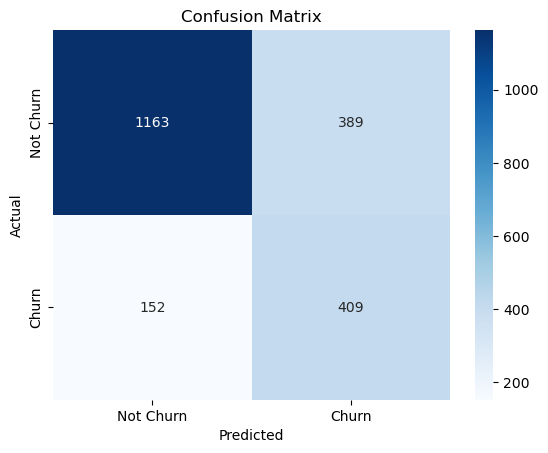


Sample Predictions:
Customer 1: Churn Probability = 0.6619, Predicted Churn = Yes
Customer 2: Churn Probability = 0.2643, Predicted Churn = No
Customer 3: Churn Probability = 0.7106, Predicted Churn = Yes
Customer 4: Churn Probability = 0.2911, Predicted Churn = No
Customer 5: Churn Probability = 0.9651, Predicted Churn = Yes


In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load dataset
data = pd.read_excel("C:/Users/User/Downloads/Churn_prediction_data.xlsx")

# Data Cleaning
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(0, inplace=True)

# Feature Engineering
def tenure_lab(data):
    if data['tenure'] <= 12:
        return "Tenure_0-12"
    elif data['tenure'] <= 24:
        return "Tenure_12-24"
    elif data['tenure'] <= 36:
        return "Tenure_24-36"
    elif data['tenure'] <= 48:
        return "Tenure_36-48"
    elif data['tenure'] <= 60:
        return "Tenure_48-60"
    else:
        return "Tenure_gt_60"

data['tenure_group'] = data.apply(tenure_lab, axis=1)
data['avg_monthly_charge'] = data['TotalCharges'] / (data['tenure'] + 0.001)
data['has_internet_service'] = data['InternetService'].apply(lambda x: 0 if x == 'No' else 1)
data['has_phone_service'] = data['PhoneService'].apply(lambda x: 1 if x == 'Yes' else 0)

services = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']
data['total_services'] = data[services].apply(lambda x: sum([1 if val == 'Yes' else 0 for val in x]), axis=1)

# Encoding Categorical Variables
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod', 'tenure_group']

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

data['Churn'] = data['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Feature Selection
X = data.drop(['Churn'], axis=1)
y = data['Churn']
selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
X = X[selected_features]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Handle Imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Feature Scaling
scaler = StandardScaler()
#num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_charge', 'total_services']
#X_train_smote[num_cols] = scaler.fit_transform(X_train_smote[num_cols])
#X_test[num_cols] = scaler.transform(X_test[num_cols])
# Only use columns that are in both num_cols and selected_features
available_num_cols = [col for col in num_cols if col in X_train_smote.columns]

X_train_smote[available_num_cols] = scaler.fit_transform(X_train_smote[available_num_cols])
X_test[available_num_cols] = scaler.transform(X_test[available_num_cols])

# Model Evaluation Function
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    return model, y_pred_proba

# Train and Evaluate Logistic Regression Model
print("\nLogistic Regression Performance:")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model, lr_probs = evaluate_model(lr_model, X_train_smote, y_train_smote, X_test, y_test)

# Save Model and Scaler
joblib.dump(lr_model, 'churn_prediction_logistic_model.pkl')
joblib.dump(scaler, 'churn_prediction_scaler.pkl')

def predict_churn(new_data):
    # Load model and scaler
    model = joblib.load('churn_prediction_logistic_model.pkl')
    scaler = joblib.load('churn_prediction_scaler.pkl')

    # Redefine key variables inside the function
    services = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
    
    cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                'PaperlessBilling', 'PaymentMethod', 'tenure_group']

    num_cols_all = ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_charge', 'total_services']

    # Create engineered features
    new_data['avg_monthly_charge'] = new_data['TotalCharges'] / (new_data['tenure'] + 0.001)
    new_data['has_internet_service'] = new_data['InternetService'].apply(lambda x: 0 if x == 'No' else 1)
    new_data['has_phone_service'] = new_data['PhoneService'].apply(lambda x: 1 if x == 'Yes' else 0)
    new_data['total_services'] = new_data[services].apply(lambda x: sum([1 if val == 'Yes' else 0 for val in x]), axis=1)

    # Encode categorical columns
    for col in cat_cols:
        le = LabelEncoder()
        le.fit(data[col])  # NOTE: Should use saved encoders in production
        new_data[col] = le.transform(new_data[col])

    # Keep only selected features
    new_data = new_data[selected_features]

    # Safely scale only available numeric columns
    existing_num_cols = [col for col in num_cols_all if col in new_data.columns]
    new_data[existing_num_cols] = scaler.transform(new_data[existing_num_cols])

    # Make predictions
    churn_prob = model.predict_proba(new_data)[:, 1]
    churn_pred = (churn_prob >= 0.5).astype(int)

    return churn_prob, churn_pred


# Test Prediction
sample_data = data.iloc[:5].copy()


sample_data['tenure'] = [5, 10, 15, 20, 25]
sample_data['MonthlyCharges'] = [50, 75, 100, 125, 150]

probabilities, predictions = predict_churn(sample_data)

print("\nSample Predictions:")
for i, (prob, pred) in enumerate(zip(probabilities, predictions)):
    print(f"Customer {i+1}: Churn Probability = {prob:.4f}, Predicted Churn = {'Yes' if pred == 1 else 'No'}")
